## Prova 1 - Ciência de dados
#### Rafael Grabowski de Lima

#### importando libs

In [2]:
# manipulação de dados e calculos numéricos
import pandas as pd
import numpy as np
# libs de vizualização
import matplotlib.pyplot as plt
import seaborn as sns
# Função que separa os dados em treinamento e teste
from sklearn.model_selection import train_test_split
# Modelo de regressão linear
from sklearn.linear_model import LinearRegression
# Métricas utilizadas para avaliar o modelo
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [6]:
sns.set_theme(style="darkgrid")
SEMENTE=42 # Semente fixa para que os resultados possam ser reproduzidos

#### Criando e verficando o dataset

In [8]:
# Carrega o arquivo CSV e armazena os dados em um DataFrame
dataset = pd.read_csv('student_scores.csv')
dataset.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [10]:
#verificando estrutura
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [12]:
# Conta os valores ausentes de cada coluna
print('Valores ausentes:')
print(dataset.isnull().sum())

# Conta as linhas completamente duplicadas
print('\nRegistros duplicados:')
print(dataset.duplicated().sum())

Valores ausentes:
Hours     0
Scores    0
dtype: int64

Registros duplicados:
0


In [13]:
# visualizando estatisticas
dataset.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


#### Relação entre Horas de estudo e nota antes do treinamento

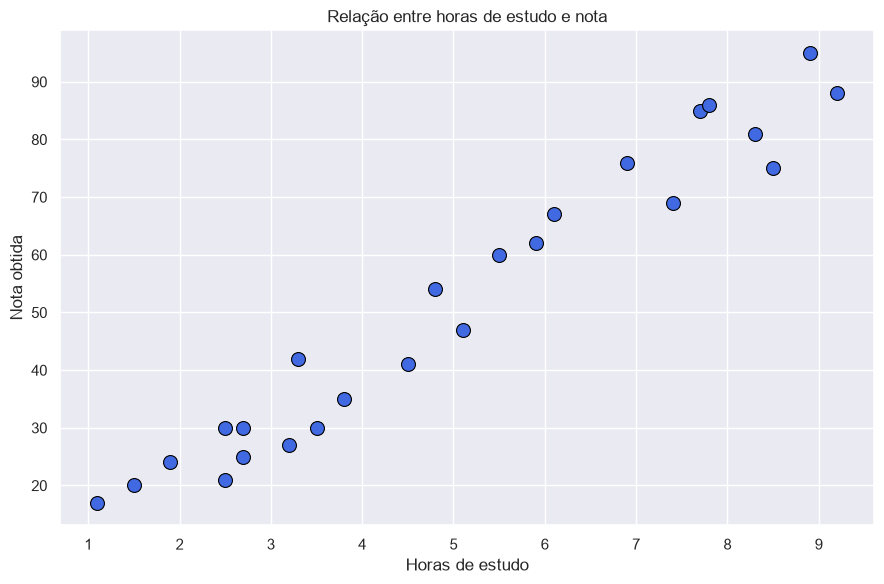

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=dataset,
    x='Hours',
    y='Scores',
    s=100,
    color='royalblue',
    edgecolor='black'
)

plt.title('Relação entre horas de estudo e nota')
plt.xlabel('Horas de estudo')
plt.ylabel('Nota obtida')
plt.tight_layout()
plt.show()

O gráfico mostra uma relação positiva entre as duas variáveis. De maneira
geral, estudantes que dedicaram mais horas aos estudos obtiveram notas
maiores. Esse comportamento aproximadamente linear indica que a regressão
linear simples pode ser adequada para representar a relação entre as variáveis.

In [17]:
#X contém a variável independente utilizada para fazer as previsões.
#Foram usados dois colchetes para que X permaneça no formato de tabela.
X = dataset[['Hours']]

# y contém a variável dependente que o modelo deverá prever.
y = dataset['Scores']

print('Formato de X:', X.shape)
print('Formato de y:', y.shape)

Formato de X: (25, 1)
Formato de y: (25,)


#### Dividindo os dados em treinamento e teste

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # 20% dos registros para teste
    random_state=SEMENTE
)

print(f'Registros de treinamento: {len(X_train)}')
print(f'Registros de teste: {len(X_test)}')

Registros de treinamento: 20
Registros de teste: 5



O conjunto de treinamento será usado pelo algoritmo para aprender a relação entre horas e notas. O conjunto de teste será usado somente depois do treinamento, permitindo avaliar o modelo com registros que ele não utilizou para aprender.

In [22]:
#Cria uma instância do modelo de regressão linear
modelo = LinearRegression()
#O método fit encontra a reta que melhor representa os dados de treinamento
modelo.fit(X_train, y_train)

print('Modelo treinado!')

Modelo treinado!


In [25]:
#O coeficiente angular indica quanto a nota aumenta
#para cada hora adicional de estudo.
coeficiente_angular = modelo.coef_[0]

#O intercepto representa a nota estimada quando Hours é igual a zero.
intercepto = modelo.intercept_

print(f'coeficiente angular: {coeficiente_angular:.4f}')
print(f'Intercepto: {intercepto:.4f}')

print(
    f'Scores = {intercepto:.4f} + '
    f'({coeficiente_angular:.4f} × Hours)'
)

coeficiente angular: 9.6821
Intercepto: 2.8269
Scores = 2.8269 + (9.6821 × Hours)


#### equação geral da regressão
Scores = intercepto + coeficiente × Hours


#### Previsões no conjunto de teste

In [ ]:
# Utiliza o modelo treinado para estimar as notas do conjunto de teste
y_pred = modelo.predict(X_test)
# Cria uma tabela para comparar os valores reais com os previstos
comparacao = X_test.copy()
comparacao['Score_real'] = y_test
comparacao['Score_previsto'] = y_pred
# Calcula a diferença entre a nota real e a prevista
comparacao['Erro'] = (
    comparacao['Score_real'] -
    comparacao['Score_previsto']
)

#Organiza a tabela pelo número de horas
comparacao = comparacao.sort_values('Hours')
comparacao.round(2)

,Hours,Score_real,Score_previsto,Erro
16,2.5,30,27.03,2.97
0,2.5,21,27.03,-6.03
11,5.9,62,59.95,2.05
23,6.9,76,69.63,6.37
8,8.3,81,83.19,-2.19


#### Um erro próximo de zero indica que a previsão ficou próxima da nota real.

#### calcular as métricas do modelo

In [28]:
# R² mede quanto da variação das notas é explicada pelo modelo
r2 = r2_score(y_test, y_pred)

# MAE representa a média dos erros absolutos
mae = mean_absolute_error(y_test, y_pred)

# MSE dá mais peso aos erros de maior tamanho
mse = mean_squared_error(y_test, y_pred)

# RMSE retorna o erro para a unidade original das notas
rmse = np.sqrt(mse)

print(f'R²: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')

R²: 0.9678
MAE: 3.9208
MSE: 18.9432
RMSE: 4.3524


### Interpretação das métricas

O modelo de regressão linear apresentou um **R² de 0,9678**, indicando que aproximadamente **96,78% da variação das notas** pode ser explicada pela quantidade de horas estudadas. Esse resultado demonstra uma relação linear forte entre as duas variáveis.

O **MAE foi de 3,9208**, o que significa que as notas previstas pelo modelo diferem das notas reais, em média, cerca de **3,92 pontos**.

O **MSE foi de 18,9432**. Essa métrica calcula a média dos erros elevados ao quadrado e, por isso, atribui maior peso aos erros mais elevados. Sua unidade também fica elevada ao quadrado, tornando sua interpretação direta menos intuitiva.

O **RMSE foi de 4,3524**, indicando que o erro típico das previsões é de aproximadamente **4,35 pontos na nota**. Diferentemente do MSE, o RMSE utiliza a mesma unidade da variável `Scores`, facilitando sua interpretação.

De modo geral, os resultados indicam que o modelo conseguiu representar adequadamente a relação entre horas de estudo e nota. Entretanto, como a base possui poucos registros e o conjunto de teste é pequeno, as métricas devem ser interpretadas com cautela. A avaliação com uma quantidade maior de estudantes permitiria verificar melhor a capacidade de generalização do modelo

#### Mostrando os dados e reta de regressão

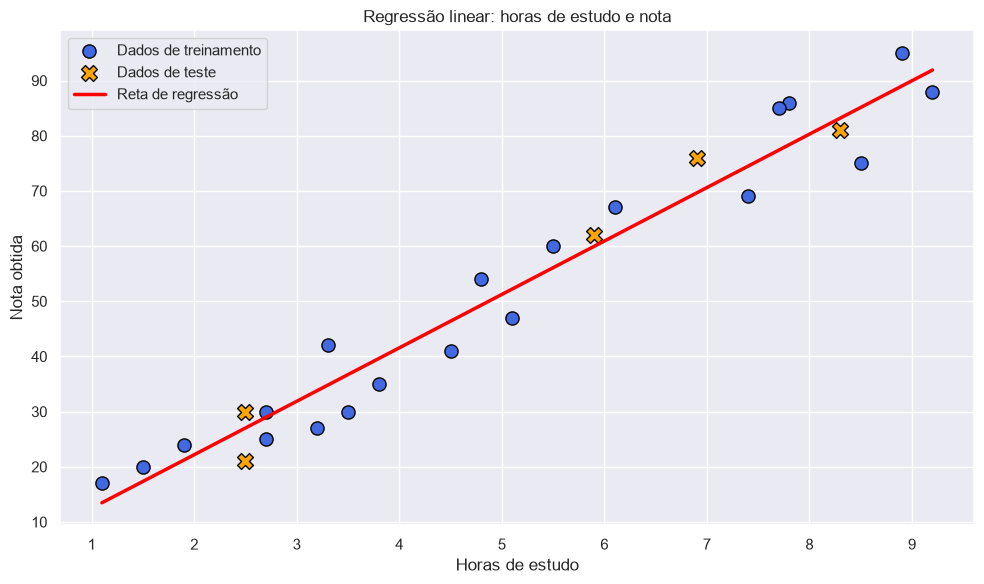

In [29]:
# Cria vários valores de horas entre o menor e o maior valor da base.
# Esses valores serão utilizados para desenhar uma linha contínua.
horas_reta = np.linspace(
    dataset['Hours'].min(),
    dataset['Hours'].max(),
    100
)
#Converte os valores para um DataFrame com o mesmo nome de coluna
#utilizado durante o treinamento.
dados_reta = pd.DataFrame({
    'Hours': horas_reta
})

# Calcula a nota prevista para cada ponto da linha
scores_reta = modelo.predict(dados_reta)
plt.figure(figsize=(10, 6))

# Pontos utilizados no treinamento
plt.scatter(
    X_train['Hours'],
    y_train,
    color='royalblue',
    edgecolor='black',
    s=90,
    label='Dados de treinamento'
)

# Pontos reservados para o teste
plt.scatter(
    X_test['Hours'],
    y_test,
    color='orange',
    edgecolor='black',
    marker='X',
    s=130,
    label='Dados de teste'
)

# Reta encontrada pelo modelo
plt.plot(
    horas_reta,
    scores_reta,
    color='red',
    linewidth=2.5,
    label='Reta de regressão'
)

plt.title('Regressão linear: horas de estudo e nota')
plt.xlabel('Horas de estudo')
plt.ylabel('Nota obtida')
plt.legend()
plt.tight_layout()
plt.show()

A linha vermelha representa a relação estimada pelo modelo entre horas de
estudo e nota. Os pontos próximos da linha possuem valores previstos próximos
dos valores reais. A inclinação positiva da reta confirma que o aumento das
horas de estudo está associado ao aumento da nota prevista.

#### podemos fazer previsões com valores inéditos

In [ ]:
# Novas quantidades de horas para as quais desejamos prever as notas
novos_estudantes = pd.DataFrame({
    'Hours': [4.0, 6.5, 7.0, 10.0]
})
# Confere se algum dos valores escolhidos já existe na base
novos_estudantes['Existe_na_base'] = novos_estudantes['Hours'].isin(
    dataset['Hours']
)
# Realiza as previsões usando o modelo treinado
novos_estudantes['Score_previsto'] = modelo.predict(
    novos_estudantes[['Hours']]
)
novos_estudantes.round(2)

# O valor de 10 horas está fora do intervalo original da base e representa uma extrapolação. 
# A previsão pode ser mostrada, mas deve ser interpretada com mais cautela.

,Hours,Existe_na_base,Score_previsto
0,4.0,False,41.56
1,6.5,False,65.76
2,7.0,False,70.60
3,10.0,False,99.65


## Conclusão

O modelo de regressão linear simples foi utilizado para estimar a nota de um
estudante a partir da quantidade de horas estudadas. A reta encontrada possui
inclinação positiva, indicando que o aumento das horas de estudo está associado
ao aumento da nota prevista.

O desempenho foi avaliado por meio do R², MAE, MSE e RMSE. O R² indica a
proporção da variação das notas explicada pelo modelo, enquanto as demais
métricas apresentam o tamanho dos erros das previsões.

Por fim, o modelo foi utilizado para prever as notas de estudantes com
quantidades de horas diferentes das observadas nos conjuntos de treinamento e
teste. Previsões fora do intervalo original devem ser interpretadas com cautela,
pois representam extrapolações.